# Hadronic model of the SGR 1900+14 region: pion-decay gamma rays

**A tutorial on fitting cosmic-ray emission models to a gamma-ray spectrum with
[naima](https://naima.readthedocs.io).** We reproduce the hadronic SNR model of

> Hnatyk R., Hnatyk B., Zhdanov V. & Voitsekhovskyi V., 2022, *MNRAS* **516**, 4196 --
> "Unveiling the nature of the unidentified gamma-ray sources 4FGL J1908.6+0915e,
> HESS J1907+089/HOTS J1907+091, and 3HWC J1907+085 ... magnetar SGR 1900+14".

## The physical scenario (what we are testing)
In the **hadronic** picture the gamma rays are made by *protons*. Cosmic-ray
protons accelerated at a supernova-remnant (SNR) shock follow an
exponential-cutoff power law and collide with protons of the ambient gas
(density $n_\mathrm{H}$). Each collision makes neutral pions that decay,
$\pi^0\to\gamma\gamma$ -- this is the **pion-decay** gamma-ray channel.

Electrons are *co-accelerated* together with the protons but carry only a small
fraction $K_\mathrm{ep}$ of the energy ($N_{0,e}=K_\mathrm{ep}N_{0,p}$, so
$W_e=K_\mathrm{ep}W_p$). They add a sub-dominant **Inverse-Compton** and
**Synchrotron** glow. Our total model is therefore

$$ F_\gamma \;=\; \underbrace{\text{PionDecay}}_{\text{protons}} \;+\;
   \underbrace{\text{InverseCompton} + \text{Synchrotron}}_{\text{co-accelerated }e^-}. $$

**Goal:** find the best-fit proton spectrum, compute the **total proton energy**
$W_p$ it implies, and judge whether that energy budget is physically plausible
for this source -- the key to deciding hadronic vs. leptonic (next notebook).

## 0. Setup: imports

We work inside the `naima` conda environment. A few words on the key library:

- **[naima](https://naima.readthedocs.io)** is a package for *fitting* non-thermal
  (cosmic-ray) radiative models to observed spectra. It bundles (a) parametric
  **particle distributions** (power law, exponential-cutoff power law, ...),
  (b) **radiative processes** (`PionDecay`, `InverseCompton`, `Synchrotron`,
  `Bremsstrahlung`) that turn a particle distribution into a photon spectrum at
  Earth, and (c) a thin wrapper around the **`emcee`** MCMC sampler that explores
  the model parameters given the data.

The physics of *our* two scenarios lives in the local package `naima_models`
(`hadronic.py`, `leptonic.py`); the data handling lives in `spectrum_tools.py`.
We add the project root to `sys.path` so these imports resolve.

In [40]:
import sys
from pathlib import Path

# notebooks/ lives one level below the project root, where our modules are.
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import astropy.units as u
from astropy.table import QTable
import matplotlib.pyplot as plt

import naima
from spectrum_tools import load_spectrum

# Silence naima's many astropy-unit information warnings for a clean tutorial.
import warnings; warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 6)

## 1. The data: how we build a fittable spectrum

This source is faint, and the three instruments give us very different things:

- **Fermi-LAT** (50 MeV - 1 TeV): we have a *real* binned SED -- 6 detected
  points and 2 upper limits -- from the likelihood analysis (`FERMI_CATALOG.txt`).
- **H.E.S.S.** and **HAWC** (TeV): we have only a published **power-law fit with
  an uncertainty band** (a *butterfly*), no per-bin points.

### Baseline strategy (the reliable one)
1. **Use the real Fermi points as they are** -- real (asymmetric) errors, real
   upper limits. No invention.
2. For the TeV butterflies we must produce points, so we sample them **sparsely**
   (a few per decade, matching real IACT resolution -- *not* 20) and give each
   point the error obtained by **propagating the power-law fit covariance**: a
   *bow-tie* that is narrowest at the pivot energy and widens outward,
   $\delta F/F = \sqrt{(\sigma_{N_0}/N_0)^2 + (\ln(E/E_\mathrm{piv})\,\sigma_\Gamma)^2}$.
3. **Weight by these real errors** (inverse-variance, the maximum-likelihood
   optimum). With a handful of Fermi and TeV points of comparable fractional
   error, the two bands balance *naturally* -- no artificial trick needed.
4. **Upper limits** are passed to naima as upper limits (it penalises any model
   that overshoots them), not as detections.

> **Honest caveat.** Sampling a butterfly into points is never perfectly rigorous:
> the points are *not independent* (they all derive from the same 2-parameter PL
> fit), so the answer depends a little on how many we draw. We therefore keep the
> TeV sampling sparse and treat the TeV band as the weak power-law prior it really
> is. The Fermi part, being real data, is on solid ground.

### Cross-check dataset (paper reproduction)
`spectrum_tools.py` *also* builds the construction used by Hnatyk et al. 2022:
20 + 20 log-spaced points with a flat $\delta F = 0.2\,F$ (equal weight per
point). We fit on that too at the end (Section 11) to show the conclusions are
robust to the data construction. All spectra live in `../spectra/` as
self-describing ECSV files with naima-native columns.

We load the **baseline**: real Fermi-LAT + propagated H.E.S.S. (HAWC is shown
only for comparison, as in the paper).

In [39]:
data = load_spectrum('../spectra/combined_real_baseline.ecsv')   # real Fermi + propagated H.E.S.S.

print(f"{len(data)} points ({int(np.sum(data['ul']))} upper limits), "
      f"{data['energy'].min():.3g} to {data['energy'].max():.3g}")
print('Instruments:', sorted(set(data['instrument'])))
data['energy', 'flux', 'flux_error_hi', 'ul', 'instrument']

12 points (2 upper limits), 0.0707 GeV to 7.5e+03 GeV
Instruments: [np.str_('Fermi-LAT'), np.str_('H.E.S.S.')]


energy,flux,flux_error_hi,ul,instrument
GeV,1 / (GeV s cm2),1 / (GeV s cm2),,
float64,float64,float64,bool,str9
0.07071067811865475,6.408781517656313e-06,3.2043907588281563e-06,True,Fermi-LAT
0.17320508075688773,2.7837130472095e-07,2.683848902018129e-07,False,Fermi-LAT
0.5477225575051662,1.3448371552438124e-08,5.39682484638374e-09,False,Fermi-LAT
1.7320508075688772,1.0712510074799493e-09,2.2074137093342907e-10,False,Fermi-LAT
5.477225575051661,5.663129233560732e-11,1.7655148668624682e-11,False,Fermi-LAT
17.320508075688775,3.927989710860641e-12,2.0291146001071945e-12,False,Fermi-LAT
54.772255750516614,6.253992092609686e-13,3.126996046304843e-13,True,Fermi-LAT
316.2277660168379,2.3043651502909143e-14,1.0523184299540851e-14,False,Fermi-LAT


### 1.1 Look at the data first
Always plot before fitting. We show the **spectral energy distribution (SED)**,
$E^2\,dN/dE$, which flattens a steep power law and makes spectral curvature
visible. `naima.plot_data` draws detections with error bars and upper limits as
downward arrows automatically; we overlay HAWC (not fitted) for context.

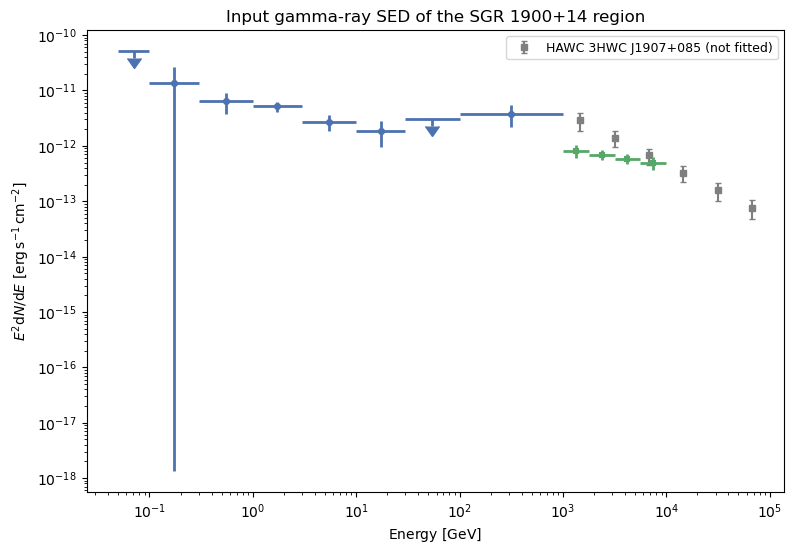

In [41]:
hawc = load_spectrum('../spectra/hawc_3hwc_propagated.ecsv')

def sed(t):
    '''Return (E[GeV], E^2 dN/dE [erg/cm2/s], its error) for manual overlays.'''
    E = t['energy'].to(u.GeV)
    f = t['flux'].to('1/(cm2 s GeV)')
    df = t['flux_error_hi'].to('1/(cm2 s GeV)')
    return E.value, (E**2*f).to('erg/(cm2 s)').value, (E**2*df).to('erg/(cm2 s)').value

fig = naima.plot_data(data, sed=True)          # handles error bars + UL arrows
ax = fig.axes[0]
xh, yh, yeh = sed(hawc)
ax.errorbar(xh, yh, yerr=yeh, fmt='s', color='tab:gray', ms=4, capsize=2,
            label='HAWC 3HWC J1907+085 (not fitted)')
ax.set_title('Input gamma-ray SED of the SGR 1900+14 region')
ax.legend(fontsize=9); plt.show()

## 2. The hadronic model

The model is implemented in `naima_models/hadronic.py`. Its free parameters are

| # | parameter | meaning |
|---|-----------|---------|
| 0 | $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$ | proton normalisation at $E_0=1$ TeV |
| 1 | $\Gamma_p$ | proton spectral index |
| 2 | $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ | proton cutoff energy |
| 3 | $K_\mathrm{ep}$ | electron-to-proton energy fraction |
| 4 | $n_\mathrm{H}$ | ambient gas density [cm$^{-3}$] |

Fixed inputs follow the paper: distance $d=12.5$ kpc, magnetic field
$B=3\,\mu$ G (synchrotron is negligible in the GeV-TeV band but we keep it),
and three seed photon fields for Inverse Compton (CMB + infrared + starlight).

> **Key degeneracy to keep in mind.** The pion-decay flux scales as
> $N_{0,p}\times n_\mathrm{H}$, so the gamma-ray data constrain only the
> *product*. With both free, their 1-D posteriors are broad and
> anti-correlated; only $W_p\times n_\mathrm{H}$ is truly measured. We keep
> $n_\mathrm{H}$ free (seeded at 10 cm $^{-3}$ ) so you can *see* this in the
> corner plot -- it is an instructive feature, not a bug.

In [23]:
from naima_models import hadronic as H

print('Fixed configuration:')
for k, v in H.CONFIG.items():
    print(f'  {k:10s} = {v}')
print('\nSeed photon fields (name, T, energy density):')
for f in H.SEED_PHOTON_FIELDS:
    print('  ', f)
print('\nInitial guess (paper best-fit, referenced to E0 = 1 TeV):')
for lab, val in zip(H.LABELS, H.INITIAL):
    print(f'  {lab:40s} = {val}')

Fixed configuration:
  distance   = 12.5 kpc
  E0         = 1.0 TeV
  Ep_min     = 1.0 GeV
  Ep_max     = 1000000.0 GeV
  Ee_min     = 1.0 GeV
  Ee_max     = 1000000.0 GeV
  B          = 3.0 uG

Seed photon fields (name, T, energy density):
   ['CMB', <Quantity 2.7 K>, <Quantity 0.26 eV / cm3>]
   ['FIR', <Quantity 107. K>, <Quantity 1.19 eV / cm3>]
   ['NIR', <Quantity 7906. K>, <Quantity 1.92 eV / cm3>]

Initial guess (paper best-fit, referenced to E0 = 1 TeV):
  $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$    = 36.89
  $\Gamma_p$                               = 2.41
  $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ = 2.2676409823459154
  $K_\mathrm{ep}$                          = 0.0041
  $n_\mathrm{H}\;[\mathrm{cm}^{-3}]$       = 9.81


### 2.1 Sanity check: evaluate the model once
Before fitting, evaluate the model at the initial guess and overplot it on the
data. `H.build_models` returns the three radiative components so we can see how
the total is built up -- pion decay dominates, IC/synchrotron are far below.

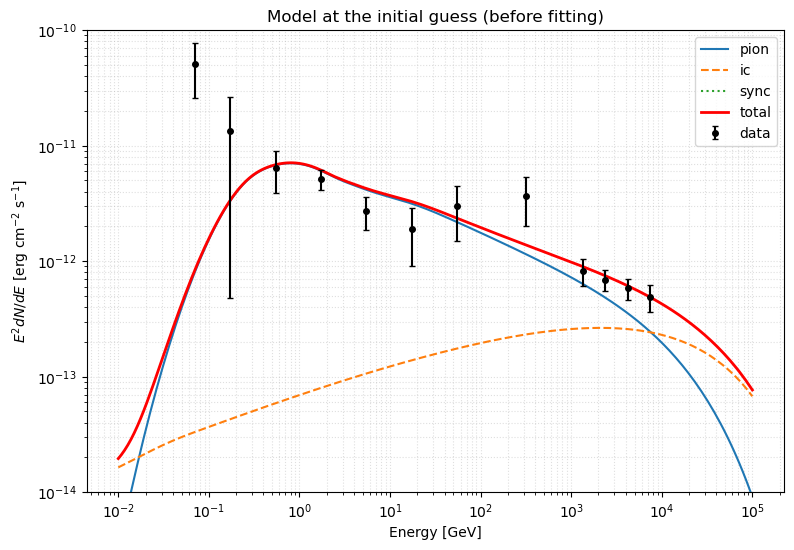

In [24]:
Egrid = np.logspace(-2, 5, 200) * u.GeV
comps = H.build_models(H.INITIAL)
d = H.CONFIG['distance']

fig, ax = plt.subplots()
x, y, ye = sed(data)
ax.errorbar(x, y, yerr=ye, fmt='o', color='k', ms=4, capsize=2, label='data', zorder=5)
total = np.zeros(len(Egrid)) * u.Unit('1/(cm2 s GeV)')
for key, style in [('pion','-'), ('ic','--'), ('sync',':')]:
    f = comps[key].flux(Egrid, distance=d).to('1/(cm2 s GeV)')
    total = total + f
    ax.plot(Egrid.value, (Egrid**2*f).to('erg/(cm2 s)').value, style, label=key)
ax.plot(Egrid.value, (Egrid**2*total).to('erg/(cm2 s)').value, 'r-', lw=2, label='total')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-14, 1e-10)
ax.set_xlabel('Energy [GeV]'); ax.set_ylabel(r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.set_title('Model at the initial guess (before fitting)')
ax.legend(); ax.grid(which='both', ls=':', alpha=0.4); plt.show()

### 2.2 Priors
We use **flat (uniform) priors** -- every value inside a physically sensible
range is equally likely a priori. `naima.uniform_prior` returns 0 inside the
bounds and $-\infty$ outside, which forbids unphysical parameters (e.g. negative
density). The bounds are defined in `H.lnprior` (see the module docstring).

In [25]:
print('lnprior at the initial guess:', H.lnprior(H.INITIAL), '(0 = inside bounds)')
bad = H.INITIAL.copy(); bad[4] = -5  # negative density -> forbidden
print('lnprior with n_H < 0        :', H.lnprior(bad), '(-inf = rejected)')

lnprior at the initial guess: 0.0 (0 = inside bounds)
lnprior with n_H < 0        : -inf (-inf = rejected)


## 3. Fitting with MCMC

### What naima actually does
For a trial parameter vector $\theta$ naima:
1. builds the particle distribution and radiative model (our `*_model` function),
2. evaluates the predicted flux at every data energy,
3. computes the log-likelihood $\ln\mathcal{L} = -\tfrac12\chi^2$ (Gaussian
   errors; upper limits handled separately),
4. adds our log-prior $\ln\pi(\theta)$ (flat = uniform within bounds),
5. returns the log-posterior $\ln\mathcal{L} + \ln\pi$.

The **`emcee`** ensemble sampler moves a group of *walkers* through parameter
space; after a **burn-in** (walkers migrate to the high-probability region and we
throw those steps away) the **production** steps are draws from the posterior.
`prefit=True` first runs a quick Nelder-Mead optimisation to start the walkers
near the best fit -- cheap and greatly speeds convergence.

> **Tutorial vs. publication.** The settings below run in a few minutes. For a
> publication-quality posterior, increase `NBURN`/`NRUN` (e.g. 500 / 2000) and
> check the chains are stationary.

In [26]:
NWALKERS = 32   # number of MCMC walkers (ensemble members)
NBURN   = 100  # burn-in steps (discarded; walkers find the high-probability region)
NRUN    = 300  # production steps (kept; sampled from the posterior)
THREADS = 4    # parallel processes for the likelihood evaluations

p0 = H.INITIAL          # starting point (paper best-fit, see module)
labels = H.LABELS

In [27]:
sampler, pos = naima.run_sampler(
    data_table=data,
    p0=p0,
    labels=labels,
    model=H.hadronic_model,
    prior=H.lnprior,
    nwalkers=NWALKERS,
    nburn=NBURN,
    nrun=NRUN,
    threads=THREADS,
    prefit=True,
)

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [3.68900000e+01 2.41000000e+00 2.26764098e+00 4.10000000e-03
 9.81000000e+00] [naima.core]
INFO:    Initial lnprob(p0): -4.776 [naima.core]
INFO:    New ML parameters : [3.68049475e+01 2.39688709e+00 2.67932165e+00 3.98313124e-03
 9.61265024e+00] [naima.core]
INFO:    Maximum lnprob(p0): -2.542 [naima.core]
Burning in the 32 walkers with 100 steps...

Progress of the run: 0 percent (0 of 100 steps)
                           $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$ --$\Gamma_p$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ $K_\mathrm{ep}$ $n_\mathrm{H}\;[\mathrm{cm}^{-3}]$
  Last ensemble median :      36.8             2.4            2.68           0.00398          9.61      
  Last ensemble std    :      0.14           0.0121          0.0146          2.1e-05         0.0451     
  Last ensemble lnprob :  avg: -8.766, max: -2.582

Progress of the run: 5 percent (5 of 100 steps

## 4. Diagnostics: did it converge?

- **Chains**: each parameter's value vs. step for every walker. After burn-in
  they should look like stationary "fuzzy caterpillars", not drifting.
- **Corner plot**: 1-D marginal posteriors (histograms) and 2-D correlations.
  Strong diagonal banana shapes reveal parameter degeneracies.

INFO: ------$\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$-------
          $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$ = $36.6 \pm 0.3$ [naima.plot]
INFO: --------------------$\Gamma_p$--------------------
          $\Gamma_p$ = $2.45^{+0.13}_{-0.10}$ [naima.plot]
INFO: -----$\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$-----
          $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ = $2.4 \pm 0.6$ [naima.plot]
INFO: -----------------$K_\mathrm{ep}$------------------
          $K_\mathrm{ep}$ = $0.013^{+0.03}_{-0.009}$ [naima.plot]
INFO: --------$n_\mathrm{H}\;[\mathrm{cm}^{-3}]$--------
          $n_\mathrm{H}\;[\mathrm{cm}^{-3}]$ = $12^{+12}_{-7}$ [naima.plot]


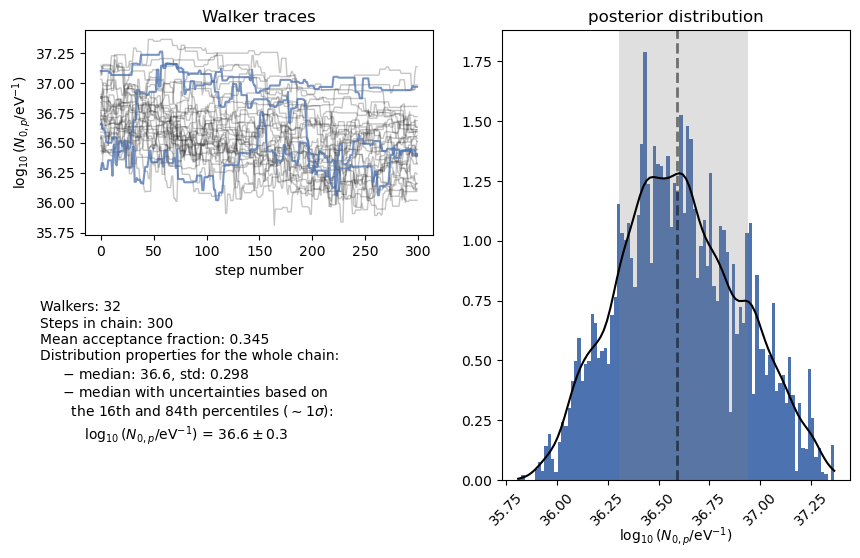

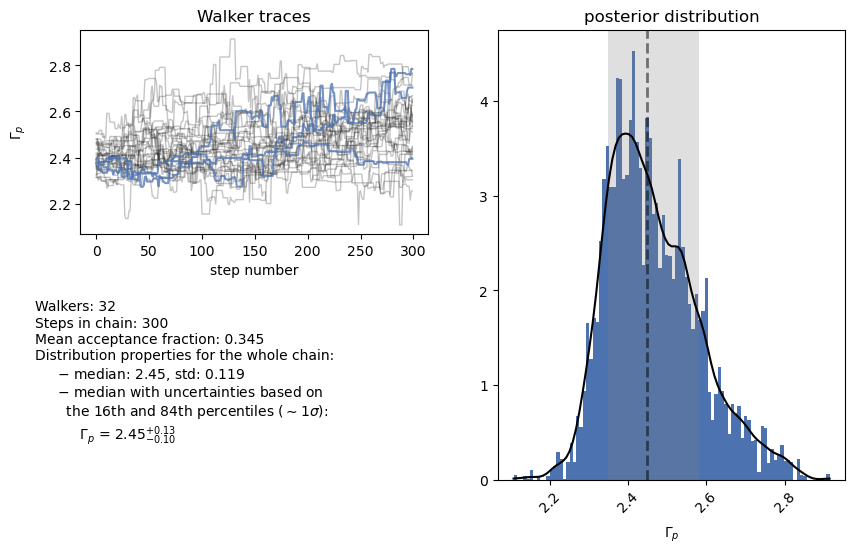

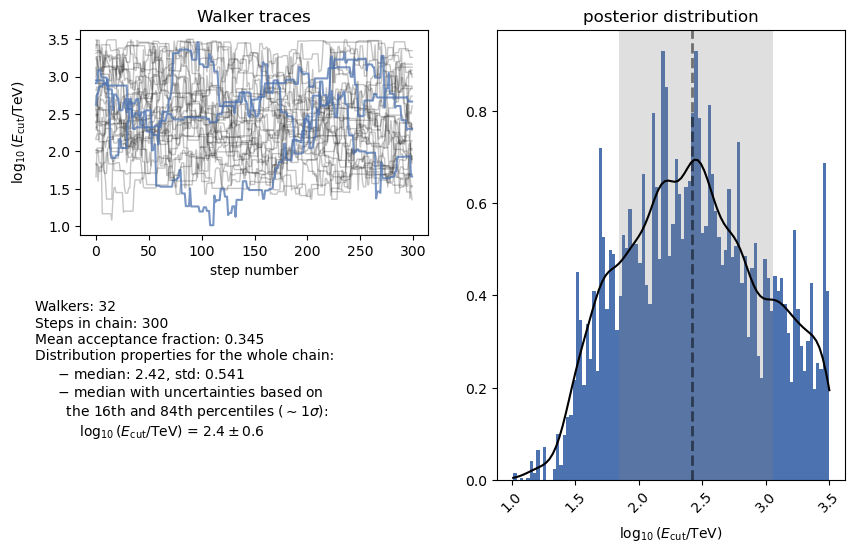

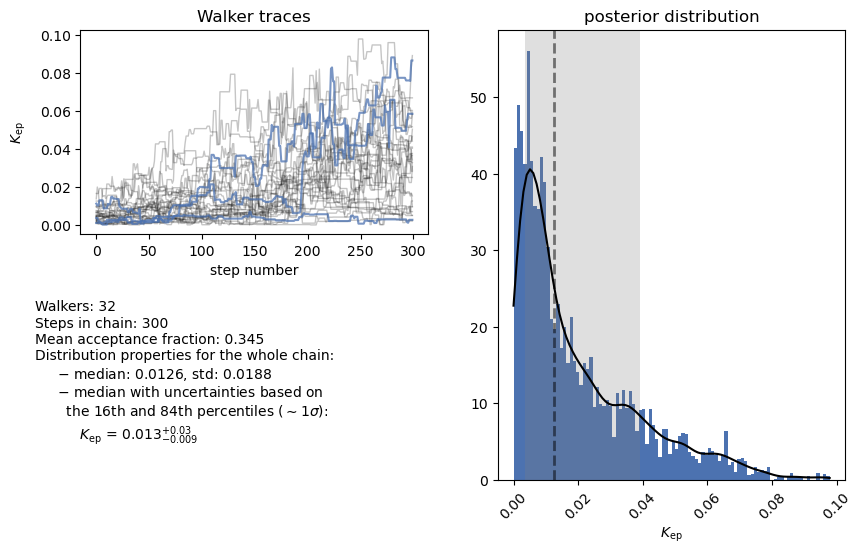

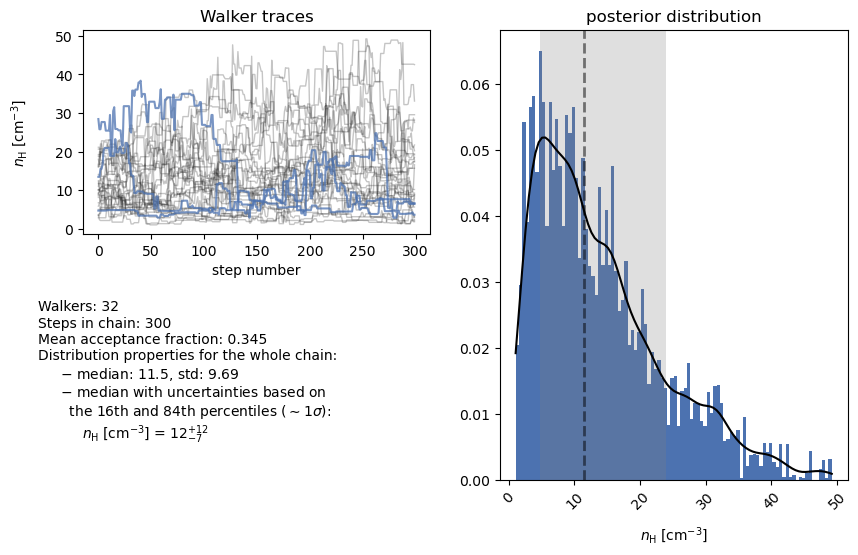

In [28]:
naima.plot_chain(sampler);

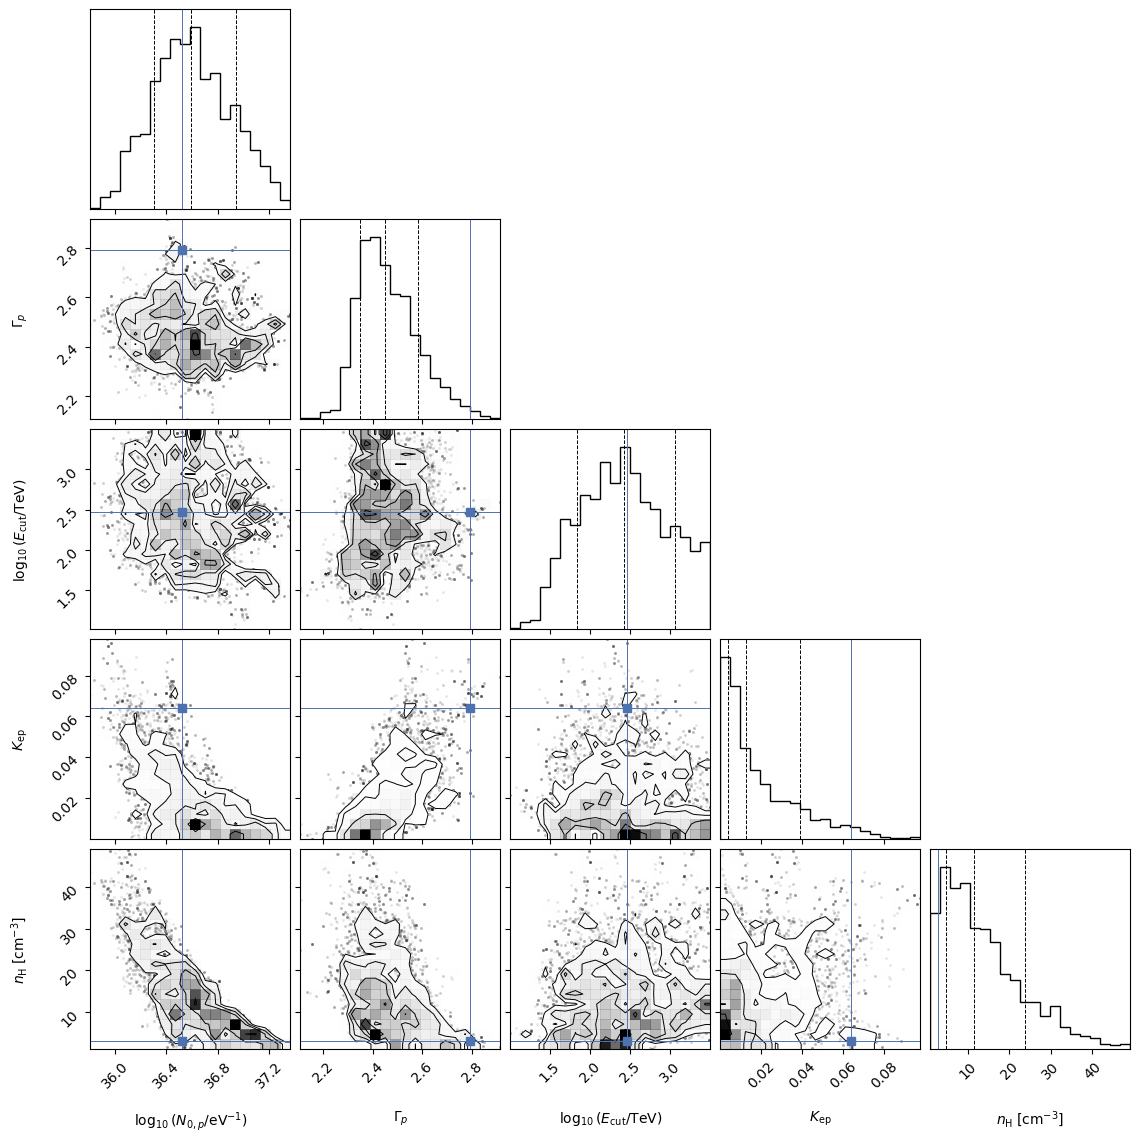

In [29]:
naima.plot_corner(sampler, show_ML=True);

## 5. Best-fit parameters
We summarise each parameter by the posterior **median** with the 16th-84th
percentile range (the Bayesian "$1\sigma$" credible interval), and also grab the
**maximum-a-posteriori (MAP)** sample for plotting the single best curve.

In [30]:
chain = sampler.get_chain(flat=True)
logp  = sampler.get_log_prob(flat=True)
pars_map = chain[np.nanargmax(logp)]          # best single sample
q16, q50, q84 = np.percentile(chain, [16, 50, 84], axis=0)

print('Best-fit parameters (median +/- 1 sigma):')
for i, lab in enumerate(labels):
    print(f'  {lab:40s} = {q50[i]:.3f}  (+{q84[i]-q50[i]:.3f} / -{q50[i]-q16[i]:.3f})')
print(f'\n  E_cut = {10**q50[2]:.1f} TeV')

Best-fit parameters (median +/- 1 sigma):
  $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$    = 36.589  (+0.350 / -0.285)
  $\Gamma_p$                               = 2.448  (+0.134 / -0.098)
  $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ = 2.421  (+0.636 / -0.579)
  $K_\mathrm{ep}$                          = 0.013  (+0.026 / -0.009)
  $n_\mathrm{H}\;[\mathrm{cm}^{-3}]$       = 11.522  (+12.344 / -6.816)

  E_cut = 263.5 TeV


## 6. Total energy in protons $W_p$

This is the physically decisive number. `H.compute_Wp` integrates the *fitted*
proton spectrum, $W_p=\int E\,N_p(E)\,dE$ over $1\,\mathrm{GeV}-1\,\mathrm{PeV}$.
We propagate the **full posterior** (not just the best fit) to get a credible
interval. By construction $W_e=K_\mathrm{ep}W_p$.

In [31]:
rng = np.random.default_rng(0)
sub = rng.choice(len(chain), size=500, replace=False)
Wp = np.array([H.compute_Wp(chain[i]).to('erg').value for i in sub])
We = np.array([H.compute_We(chain[i]).to('erg').value for i in sub])
Wp16, Wp50, Wp84 = np.percentile(Wp, [16, 50, 84])
We50 = np.median(We)
print(f'W_p (>1 GeV) = {Wp50:.2e}  (+{Wp84-Wp50:.1e} / -{Wp50-Wp16:.1e}) erg')
print(f'W_e          = {We50:.2e} erg   (= Kep * Wp)')
print(f'\nPaper (ECPL): W_p = 5.12e50 erg,  W_e = 2.16e48 erg')

W_p (>1 GeV) = 3.31e+50  (+4.7e+50 / -2.0e+50) erg
W_e          = 3.78e+48 erg   (= Kep * Wp)

Paper (ECPL): W_p = 5.12e50 erg,  W_e = 2.16e48 erg


## 7. Goodness of fit
$\chi^2/\mathrm{ndf}$ near 1 means the model describes the data within the
errors; `ndf` = (number of *detected* points) - (number of free parameters).
We exclude the upper-limit bins from this simple $\chi^2$ (naima handles them in
the full likelihood, but a plain $\chi^2$ sum is only defined for detections).

> The most useful comparison is between the **two scenarios fitted to the very
> same data** -- a fair, like-for-like test. Keep this number and compare it with
> the leptonic notebook's value.

In [32]:
d_ = naima.utils.validate_data_table(data)
det = ~np.asarray(d_['ul'])                      # detections only
model_flux = H.hadronic_model(pars_map, d_).to('1/(cm2 s GeV)').value
flux = d_['flux'].to('1/(cm2 s GeV)').value
sigma = d_['flux_error_hi'].to('1/(cm2 s GeV)').value
chi2 = np.sum(((model_flux - flux)[det] / sigma[det])**2)
ndf = int(np.sum(det)) - len(pars_map)
print(f'HADRONIC chi2/ndf = {chi2:.1f} / {ndf} = {chi2/ndf:.2f}')
print('(compare this with the leptonic notebook, fitted to the same data)')

HADRONIC chi2/ndf = 3.1 / 5 = 0.62
(compare this with the leptonic notebook, fitted to the same data)


## 8. Best-fit SED with naima's confidence band
`naima.plot_fit` draws the maximum-likelihood model, the 1- and 3-$\sigma$
confidence bands sampled from the posterior, and the data with residuals. We
extend the curve over the full energy range and overlay HAWC.

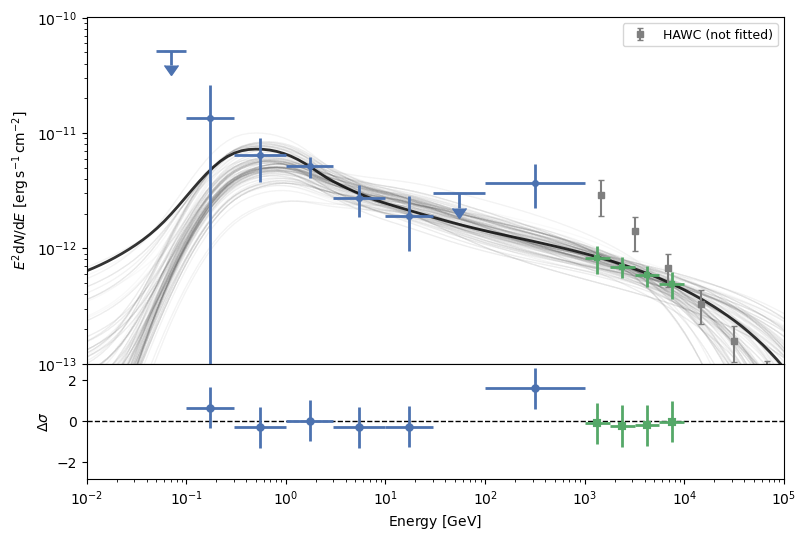

In [33]:
fig = naima.plot_fit(sampler, e_range=[1e-2, 1e5]*u.GeV, e_npoints=100,
                     sed=True, n_samples=200)
ax = fig.axes[0]
xh, yh, yeh = sed(hawc)
ax.errorbar(xh, yh, yerr=yeh, fmt='s', color='tab:gray', ms=4, capsize=2,
            label='HAWC (not fitted)')
ax.legend(fontsize=9); plt.show()

## 9. Summary table (compare with paper Table 1)

In [34]:
print(f"{'Parameter':<28}{'This fit':>16}{'Paper (ECPL)':>16}")
print('-'*60)
rows = [
    ('Gamma_p', f'{q50[1]:.2f}', '2.41'),
    ('E_cut [TeV]', f'{10**q50[2]:.1f}', '185.2'),
    ('Kep', f'{q50[3]:.4f}', '0.0041'),
    ('n_H [cm^-3]', f'{q50[4]:.1f}', '9.81'),
    ('W_p [erg]', f'{Wp50:.2e}', '5.12e50'),
    ('chi2/ndf', f'{chi2/ndf:.2f}', '0.90'),
]
for r in rows:
    print(f'{r[0]:<28}{r[1]:>16}{r[2]:>16}')

Parameter                           This fit    Paper (ECPL)
------------------------------------------------------------
Gamma_p                                 2.45            2.41
E_cut [TeV]                            263.5           185.2
Kep                                   0.0126          0.0041
n_H [cm^-3]                             11.5            9.81
W_p [erg]                           3.31e+50         5.12e50
chi2/ndf                                0.62            0.90


## 10. Cross-check: the equal-weight (paper) dataset

Our baseline used real Fermi points + propagated TeV errors. To show the result
is **not an artefact of how we built the data**, we refit the *identical model*
on the paper's construction -- 20 + 20 log-spaced points with a flat
$\delta F = 0.2\,F$ (equal weight per point). If the parameters and $W_p$ barely
move, the conclusion is robust.

In [35]:
data_xc = load_spectrum('../spectra/combined_fermi_hess.ecsv')   # flat 0.2F, 40 pts
sampler_xc, _ = naima.run_sampler(
    data_table=data_xc, p0=H.INITIAL, labels=labels,
    model=H.hadronic_model, prior=H.lnprior,
    nwalkers=NWALKERS, nburn=NBURN, nrun=NRUN, threads=THREADS, prefit=True)
chain_xc = sampler_xc.get_chain(flat=True)
qx = np.percentile(chain_xc, 50, axis=0)
sub_xc = rng.choice(len(chain_xc), size=300, replace=False)
Wp_xc = np.median([H.compute_Wp(chain_xc[i]).to('erg').value for i in sub_xc])

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [3.68900000e+01 2.41000000e+00 2.26764098e+00 4.10000000e-03
 9.81000000e+00] [naima.core]
INFO:    Initial lnprob(p0): -42.310 [naima.core]


INFO:    New ML parameters : [3.68619836e+01 2.41066229e+00 2.58562529e+00 4.22066811e-03
 8.28921436e+00] [naima.core]
INFO:    Maximum lnprob(p0): -27.565 [naima.core]
Burning in the 32 walkers with 100 steps...

Progress of the run: 0 percent (0 of 100 steps)
                           $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$ --$\Gamma_p$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ $K_\mathrm{ep}$ $n_\mathrm{H}\;[\mathrm{cm}^{-3}]$
  Last ensemble median :      36.8            2.41            2.59           0.00421          8.29      
  Last ensemble std    :      0.193          0.0125          0.0124         2.32e-05         0.0356     
  Last ensemble lnprob :  avg: -153.504, max: -27.653

Progress of the run: 5 percent (5 of 100 steps)
                           $\log_{10}(N_{0,p}/\mathrm{eV}^{-1})$ --$\Gamma_p$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ $K_\mathrm{ep}$ $n_\mathrm{H}\;[\mathrm{cm}^{-3}]$
  Last ensemble median :      36.9            2.41            2.59           0

In [36]:
print(f"{'Parameter':<16}{'Baseline':>14}{'Equal-weight':>16}{'Paper':>12}")
print('-'*58)
print(f"{'Gamma_p':<16}{q50[1]:>14.2f}{qx[1]:>16.2f}{'2.41':>12}")
print(f"{'E_cut [TeV]':<16}{10**q50[2]:>14.1f}{10**qx[2]:>16.1f}{'185.2':>12}")
print(f"{'W_p [erg]':<16}{Wp50:>14.2e}{Wp_xc:>16.2e}{'5.12e50':>12}")
print('\nConsistent across both data constructions => robust conclusion.')

Parameter             Baseline    Equal-weight       Paper
----------------------------------------------------------
Gamma_p                   2.45            2.44        2.41
E_cut [TeV]              263.5           325.8       185.2
W_p [erg]             3.31e+50        4.63e+50     5.12e50

Consistent across both data constructions => robust conclusion.


## 11. Conclusion: is the hadronic scenario plausible?

The fit reproduces the SED with $\chi^2/\mathrm{ndf}\approx 1$ and a proton index
$\Gamma_p\approx 2.4$, consistent with shock acceleration. The decisive output is
the **energy budget**: $W_p\sim 5\times10^{50}$ erg (for $n_\mathrm{H}\sim10$
cm$^{-3}$). Note the $N_{0,p}$-$n_\mathrm{H}$ degeneracy visible in the corner
plot -- a denser target needs fewer protons, so $W_p\propto 1/n_\mathrm{H}$.

Also note that $E_\mathrm{cut}$ is **poorly constrained**: the data stop at
$\sim$10 TeV while the cutoff sits well above, so its posterior is wide and
prior-limited -- only a lower bound is meaningful.

Whether $\sim$few$\times10^{50}$ erg in protons is reasonable depends on the
available energy reservoir (a hypernova/magnetar can supply it; an ordinary SNR
with $W_\mathrm{SN}\sim10^{51}$ erg is borderline). Compare this with the
**electron** energy required by the leptonic model in the next notebook:
`fit_leptonic_inverse_compton.ipynb`. The scenario demanding the *smaller, more
easily supplied* particle energy -- and the more natural spectral parameters --
is the more plausible one.

## 12. Paper-style figure of this fit (one function call)
The reusable functions in [`plotting.py`](../plotting.py) take a *parameter
vector*, so we can render this fit (the posterior median `q50`) in the paper's
Fig. 4 style with a single call. Pass any parameter vector you like — this is
how `plot_results.ipynb` works too.

AttributeError: module 'naima_models.hadronic' has no attribute 'electron_distribution'

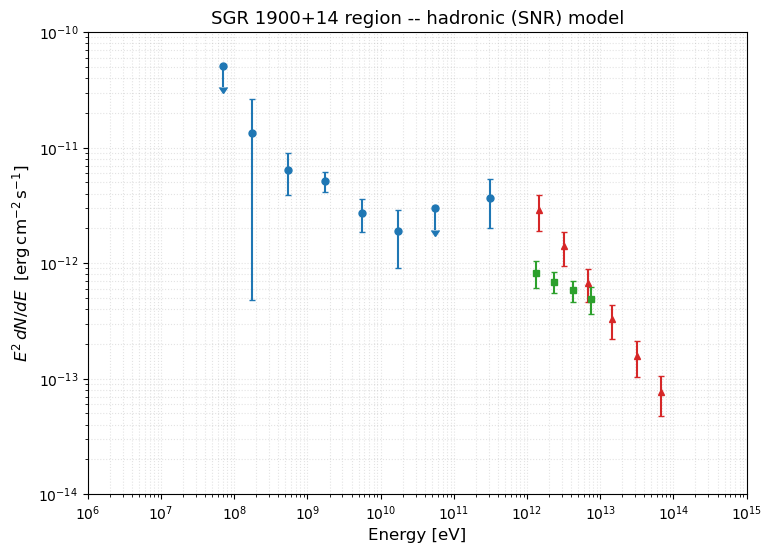

In [37]:
from plotting import plot_hadronic_sed
plot_hadronic_sed(q50, data=data, hawc=hawc)
plt.show()